GLOBAL IMPORTS AND CONFIGS

In [1]:
import os
import joblib

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix
)

from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA

ARRAY_PATH = "processed_arrays/"
MODEL_PATH = "models/"
IMAGE_PATH = "images/"

os.makedirs(IMAGE_PATH, exist_ok=True)

LOADING THE PREPROCESSED FULL DATA

In [2]:
X_full = np.load(
    os.path.join(
        ARRAY_PATH,
        "X_full.npy"
    ),
    allow_pickle=True
)

y_full = np.load(
    os.path.join(
        ARRAY_PATH,
        "y_full.npy"
    ),
    allow_pickle=True
)

feature_names = np.load(os.path.join(ARRAY_PATH, "feature_names.npy"))
target_classes = np.load(os.path.join(ARRAY_PATH, "target_classes.npy"))

print("Dataset Shape:")
print(X_full.shape)

Dataset Shape:
(1000, 19)


PCA DATA TRANSFORMATION

In [3]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_full
)

LOADING THE CLUSTERING MODELS

In [4]:
kmeans_model = joblib.load(

    os.path.join(
        MODEL_PATH,
        "kmeans_model.joblib"
    )
)

kmeans_labels = kmeans_model.labels_

hierarchical_labels = np.load(

    os.path.join(
        MODEL_PATH,
        "hierarchical_labels.npy"
    ),

    allow_pickle=True
)

gmm_labels = np.load(

    os.path.join(
        MODEL_PATH,
        "gmm_labels.npy"
    ),

    allow_pickle=True
)

In [5]:
print("K-Means Clusters")

print(pd.Series(kmeans_labels).value_counts())

print("\nHierarchical Clusters")

print(pd.Series(hierarchical_labels).value_counts())

print("\nGaussian Mixture Clusters")

print(pd.Series(gmm_labels).value_counts())

K-Means Clusters
1    753
2    234
0     13
Name: count, dtype: int64

Hierarchical Clusters
0    724
1    221
2     55
Name: count, dtype: int64

Gaussian Mixture Clusters
1    670
0    220
2    110
Name: count, dtype: int64


EVALUATING THE CLUSTERING MODELS

In [6]:
def evaluate_clustering(
    X_data,
    cluster_labels,
    true_labels
):

    metrics = {}

    metrics["Silhouette Score"] = silhouette_score(

        X_data,

        cluster_labels
    )

    metrics["Davies-Bouldin Score"] = davies_bouldin_score(

        X_data,

        cluster_labels
    )

    metrics["Calinski-Harabasz Score"] = calinski_harabasz_score(

        X_data,

        cluster_labels
    )

    metrics["Adjusted Rand Index"] = adjusted_rand_score(

        true_labels,

        cluster_labels
    )

    metrics["Normalized Mutual Information"] = normalized_mutual_info_score(

        true_labels,

        cluster_labels
    )

    return metrics


kmeans_metrics = evaluate_clustering(

    X_full,

    kmeans_labels,

    y_full
)

hierarchical_metrics = evaluate_clustering(

    X_full,

    hierarchical_labels,

    y_full
)

gmm_metrics = evaluate_clustering(

    X_full,

    gmm_labels,

    y_full
)

In [7]:
comparison_df = pd.DataFrame({

    "Metric": [

        "Silhouette Score",

        "Davies-Bouldin Score",

        "Calinski-Harabasz Score",

        "Adjusted Rand Index",

        "Normalized Mutual Information"
    ],

    "K-Means": [

        kmeans_metrics["Silhouette Score"],

        kmeans_metrics["Davies-Bouldin Score"],

        kmeans_metrics["Calinski-Harabasz Score"],

        kmeans_metrics["Adjusted Rand Index"],

        kmeans_metrics["Normalized Mutual Information"]
    ],

    "Hierarchical": [

        hierarchical_metrics["Silhouette Score"],

        hierarchical_metrics["Davies-Bouldin Score"],

        hierarchical_metrics["Calinski-Harabasz Score"],

        hierarchical_metrics["Adjusted Rand Index"],

        hierarchical_metrics["Normalized Mutual Information"]
    ],

    "Gaussian Mixture": [

        gmm_metrics["Silhouette Score"],

        gmm_metrics["Davies-Bouldin Score"],

        gmm_metrics["Calinski-Harabasz Score"],

        gmm_metrics["Adjusted Rand Index"],

        gmm_metrics["Normalized Mutual Information"]
    ]
})

comparison_df

,Metric,K-Means,Hierarchical,Gaussian Mixture
0,Silhouette Score,0.221910,0.222706,0.216481
1,Davies-Bouldin Score,1.378506,1.515881,2.598974
2,Calinski-Harabasz Score,157.718387,144.809497,122.731468
3,Adjusted Rand Index,0.587506,0.512008,0.417449
4,Normalized Mutual Information,0.447570,0.412447,0.370465


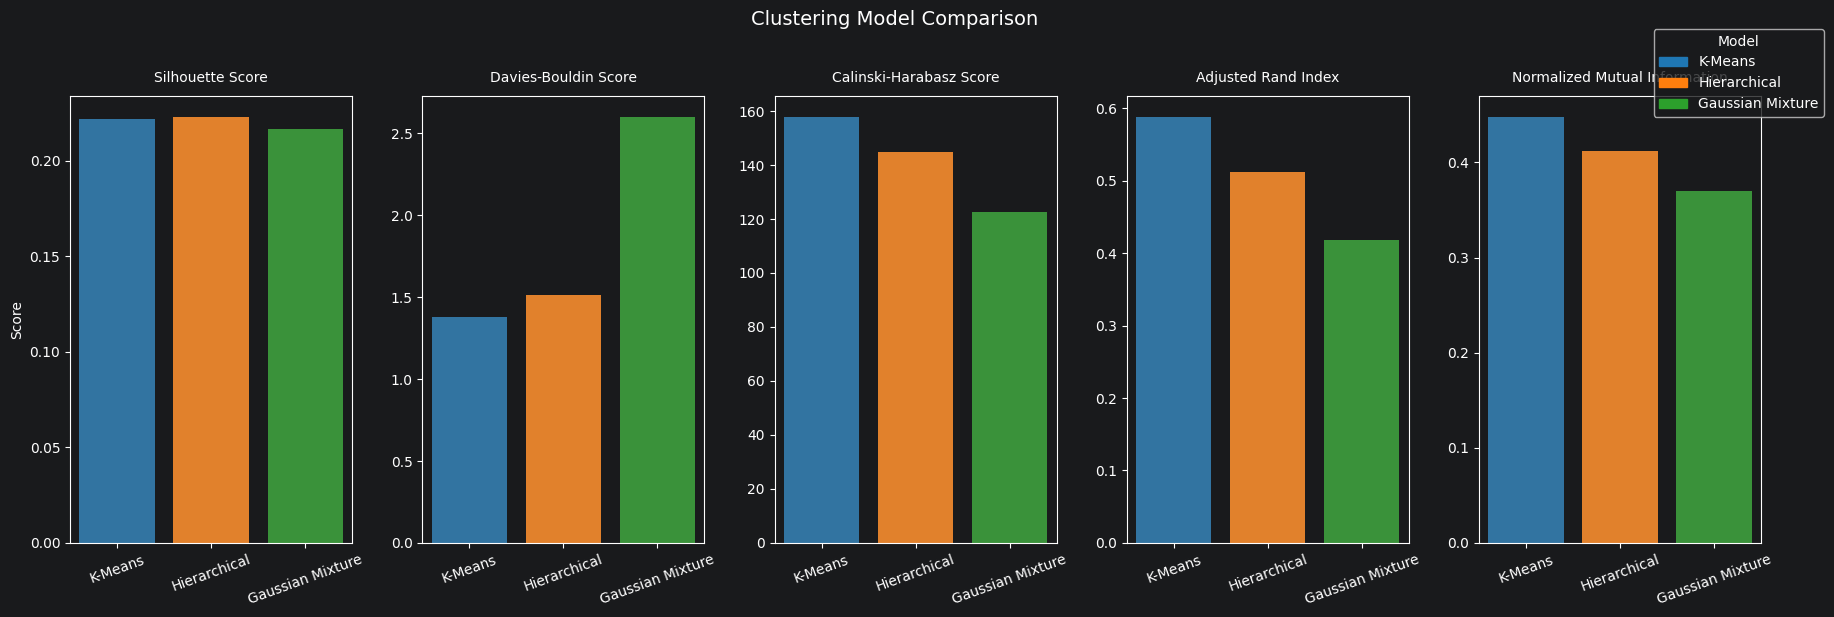

In [8]:
melted_metrics = comparison_df.melt(
    id_vars="Metric",
    var_name="Model",
    value_name="Score"
)

metrics = comparison_df["Metric"].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(metrics),
    figsize=(18, 6)
)

for ax, metric in zip(axes, metrics):

    subset = melted_metrics[
        melted_metrics["Metric"] == metric
    ]

    sns.barplot(
        data=subset,
        x="Model",
        y="Score",
        hue="Model",
        palette="tab10",
        ax=ax,
        legend=False
    )

    ax.set_title(metric, fontsize=10, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Score" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=20)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=sns.color_palette("tab10")[i])
    for i in range(len(melted_metrics["Model"].unique()))
]

fig.legend(
    handles,
    melted_metrics["Model"].unique(),
    title="Model",
    loc="upper right",
    bbox_to_anchor=(1.02, 1)
)

plt.suptitle("Clustering Model Comparison", fontsize=14, y=1.02)
plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_PATH,
        "clustering_model_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

REMAPPING CLUSTER LABELS TO MATCH ACTUAL CLASS LABELS FOR BETTER COMPARISON

In [9]:
def remap_labels(true_labels, pred_labels):
    cm = confusion_matrix(true_labels, pred_labels)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping[l] for l in pred_labels])

kmeans_remapped       = remap_labels(y_full, kmeans_labels)
hierarchical_remapped = remap_labels(y_full, hierarchical_labels)
gmm_remapped          = remap_labels(y_full, gmm_labels)

COMPARING ACTUAL VS MODEL CLUSTERS

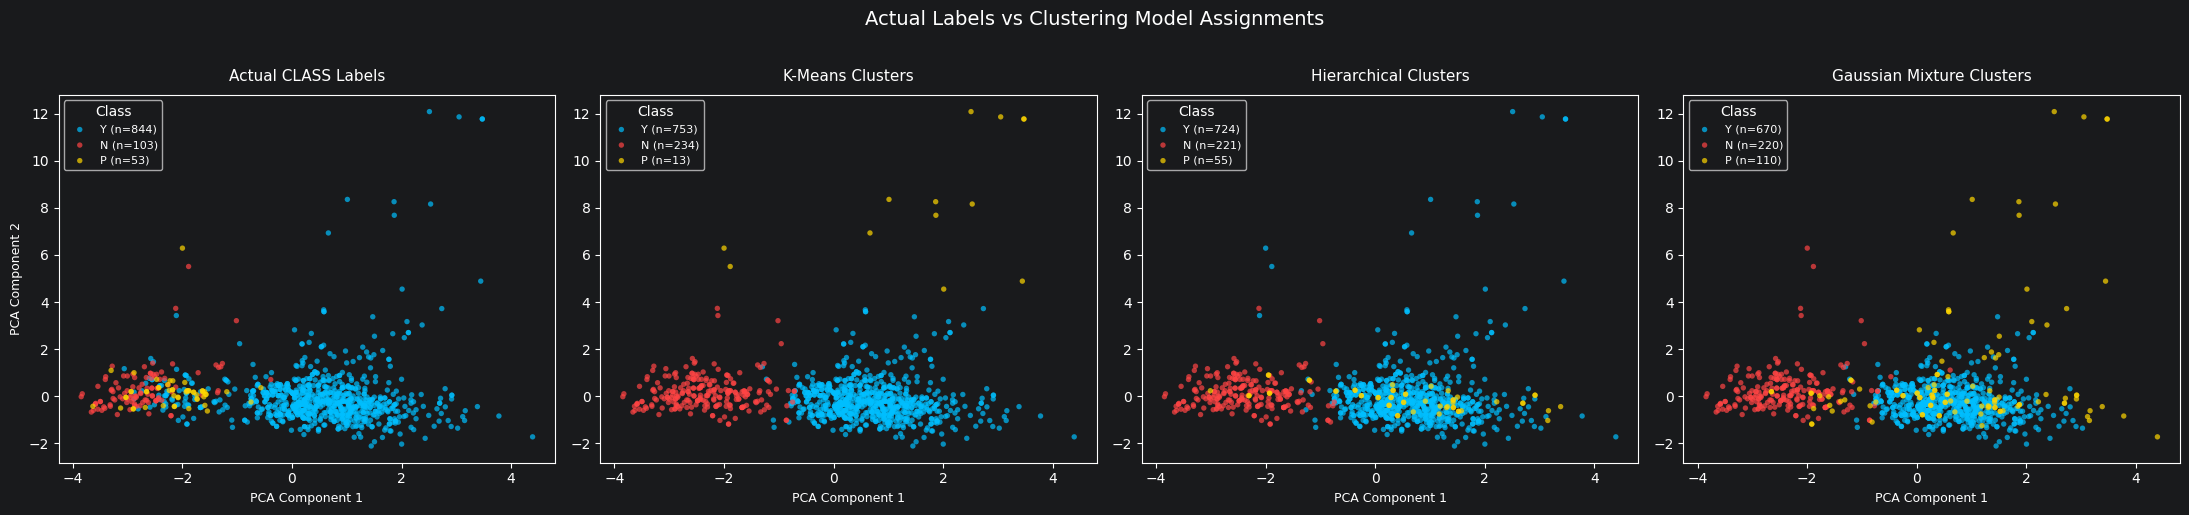

In [10]:
PALETTE = {
    0: "#FF4444",
    1: "#FFD700",
    2: "#00BFFF",
}
CLASS_NAMES = {0: "N", 1: "P", 2: "Y"}
PLOT_ORDER = [2, 0, 1]

fig, axes = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(22, 5)
)

plot_configs = [
    (y_full,               "Actual CLASS Labels"),
    (kmeans_remapped,      "K-Means Clusters"),
    (hierarchical_remapped,"Hierarchical Clusters"),
    (gmm_remapped,         "Gaussian Mixture Clusters"),
]

for ax, (labels, title) in zip(axes, plot_configs):

    for class_id in PLOT_ORDER:
        mask = labels == class_id
        ax.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            c=PALETTE[class_id],
            label=f"{CLASS_NAMES[class_id]} (n={mask.sum()})",
            alpha=0.7,
            s=15,
            edgecolors="none"
        )

    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel("PCA Component 1", fontsize=9)
    ax.set_ylabel("PCA Component 2" if ax == axes[0] else "", fontsize=9)
    ax.legend(title="Class", fontsize=8)

plt.suptitle(
    "Actual Labels vs Clustering Model Assignments",
    fontsize=14,
    y=1.02
)
plt.tight_layout()

plt.savefig(
    os.path.join(IMAGE_PATH, "actual_vs_cluster_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()